In [1]:

import pandas

In [2]:

# PREVALENCE ANALYSIS FOR HIV TREATMENT DATASET

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [3]:

df = pd.read_csv("QualityOfCare.csv")

In [4]:
# Standardize outcome variable
df['ViralLoadSuppression'] = df['ViralLoadSuppression'].str.strip().str.title()

In [5]:

##### PREVALANCE ANALYSIS FOR DEMOGRAPHIC FACTORS

# Create age categories commonly used in HIV studies
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 19, 29, 39, 49, 59, 120],
    labels=['<20', '20–29', '30–39', '40–49', '50–59', '60+']
)


In [6]:
demographic_vars = [
    'Sex',
    'AgeGroup',
    'MaritalStatus',
    'EducationLevel',
    'Occupation']


In [7]:
from scipy.stats import chi2_contingency



def prevalence_chisquare(data, variable, outcome='ViralLoadSuppression'):
    # Contingency table
    
    table = pd.crosstab(data[variable], data[outcome])
    
    # Convert to prevalence (%)
    prevalence = table.div(table.sum(axis=1), axis=0) * 100
    
    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)
    
    # Combine results
    result = table.copy()
    result['Suppressed_%'] = prevalence.get('Yes', 0).round(1)
    result['Not_Suppressed_%'] = prevalence.get('No', 0).round(1)
    
    return result, p


In [8]:
results = []

for var in demographic_vars:
    table, p_value = prevalence_chisquare(df, var)
    table['Variable'] = var
    table['Category'] = table.index
    table['ChiSquare_p_value'] = round(p_value, 4)
    results.append(table.reset_index(drop=True))


In [9]:
prevalence_results = pd.concat(results, ignore_index=True)

# Reorder columns for reporting
final_table = prevalence_results[
    ['Variable', 'Category', 'Yes', 'No',
     'Suppressed_%', 'Not_Suppressed_%', 'ChiSquare_p_value']
]

final_table


ViralLoadSuppression,Variable,Category,Yes,No,Suppressed_%,Not_Suppressed_%,ChiSquare_p_value
0,Sex,Female,9680,6781,58.8,41.2,0.0
1,Sex,Male,4216,3570,54.1,45.9,0.0
2,AgeGroup,<20,1205,1029,53.9,46.1,0.0
3,AgeGroup,20–29,2893,2407,54.6,45.4,0.0
4,AgeGroup,30–39,4674,3485,57.3,42.7,0.0
5,AgeGroup,40–49,3002,2033,59.6,40.4,0.0
6,AgeGroup,50–59,1224,878,58.2,41.8,0.0
7,AgeGroup,60+,453,315,59.0,41.0,0.0
8,MaritalStatus,Cohabiting,45,4,91.8,8.2,0.0
9,MaritalStatus,Divorced,228,146,61.0,39.0,0.0


In [10]:
#### PREVALANCE ANALYSIS FOR CLINICAL FACTORS
clinical_vars = [
    'Cd4AtStart',
    'AdherenceCouncelingCompleted',
    'ArtInterruption',
    'AnySideEffects',
    'ArvAdherenceLatestLevel'
]


In [11]:
df['Cd4Category'] = pd.cut(
    df['Cd4AtStart'],
    bins=[0, 200, 350, 500, 2000],
    labels=['<200', '200–349', '350–499', '≥500']
)

# Replace original variable
clinical_vars = [
    'Cd4Category',
    'AdherenceCouncelingCompleted',
    'AnySideEffects',
    'ArvAdherenceLatestLevel'
]


In [12]:
def prevalence_chisquare(data, variable, outcome='ViralLoadSuppression'):
    table = pd.crosstab(data[variable], data[outcome])

    # Remove empty rows
    table = table.loc[table.sum(axis=1) > 0]

    prevalence = table.div(table.sum(axis=1), axis=0) * 100

    chi2, p, dof, expected = chi2_contingency(table)

    result = table.copy()
    result['Suppressed_%'] = prevalence.get('Yes', 0).round(1)
    result['Not_Suppressed_%'] = prevalence.get('No', 0).round(1)

    return result, p


In [13]:
results = []

for var in clinical_vars:
    table, p_value = prevalence_chisquare(df, var)
    table['Variable'] = var
    table['Category'] = table.index
    table['ChiSquare_p_value'] = round(p_value, 4)
    results.append(table.reset_index(drop=True))


In [14]:
clinical_prevalence_table = pd.concat(results, ignore_index=True)

final_clinical_table = clinical_prevalence_table[
    ['Variable', 'Category', 'Yes', 'No',
     'Suppressed_%', 'Not_Suppressed_%', 'ChiSquare_p_value']
]

final_clinical_table


ViralLoadSuppression,Variable,Category,Yes,No,Suppressed_%,Not_Suppressed_%,ChiSquare_p_value
0,Cd4Category,<200,4254,3062,58.1,41.9,0.000
1,Cd4Category,200–349,3351,2177,60.6,39.4,0.000
2,Cd4Category,350–499,2124,1262,62.7,37.3,0.000
3,Cd4Category,≥500,2266,1381,62.1,37.9,0.000
4,AdherenceCouncelingCompleted,No,383,769,33.2,66.8,0.000
5,AdherenceCouncelingCompleted,Yes,13288,9303,58.8,41.2,0.000
6,AnySideEffects,No,13138,9631,57.7,42.3,0.008
7,AnySideEffects,Yes,489,293,62.5,37.5,0.008
8,ArvAdherenceLatestLevel,Fair,767,727,51.3,48.7,0.000
9,ArvAdherenceLatestLevel,Good,12650,8603,59.5,40.5,0.000


In [15]:
####PREVALENCE ANALYSIS PLOTS

import matplotlib.pyplot as plt
import seaborn as sns

# Premium publication style
sns.set_theme(
    style="whitegrid",
    context="talk",
    font_scale=1.05
)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.2,
    "grid.alpha": 0.25,
    "figure.dpi": 120
})


In [16]:
df.columns

Index(['Health facility level', 'FacilityType', 'Age', 'Sex', 'MaritalStatus',
       'EducationLevel', 'Occupation', 'CareEntryPoint', 'WeightAtStart',
       'HeightAtStart', 'FunctionalStatusAtStart', 'Cd4AtStart',
       'AdherenceCouncelingCompleted', 'InitialTbScreeningDone',
       'ArtSubstitution', 'ArtSwitch', 'ArtInterruption', 'WeightAtLastVisit',
       'HeightAtLastVisit', 'OpportunisticInfectionPresentAtLastVisit',
       'AnySideEffects', 'WasPatientReceivingArv', 'ArvAdherenceLatestLevel',
       'MostRecentCd4Count', 'ViralLoadSuppression', 'AgeGroup',
       'Cd4Category'],
      dtype='object')

In [17]:

# 3D VISUALIZATION FOR HIV PREVALENCE ANALYSIS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, Normalize
import warnings
warnings.filterwarnings('ignore')

# Set premium styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# Clean target variable
df['ViralLoadSuppression'] = df['ViralLoadSuppression'].astype(str).str.strip()
df['ViralLoadSuppression'] = df['ViralLoadSuppression'].replace({
    'Yes': 1, 'No': 0, '1': 1, '0': 0, 'yes': 1, 'no': 0,
    'Y': 1, 'N': 0, 'y': 1, 'n': 0
})
df['ViralLoadSuppression'] = pd.to_numeric(df['ViralLoadSuppression'], errors='coerce')

# Create age groups
df['AgeGroup'] = pd.cut(df['Age'], 
                         bins=[0, 18, 30, 40, 50, 60, 100],
                         labels=['<18', '18-30', '31-40', '41-50', '51-60', '60+'])

# Clean Sex column
df['Sex'] = df['Sex'].astype(str).str.strip()
df['Sex'] = df['Sex'].replace({'male': 'Male', 'female': 'Female', 'M': 'Male', 'F': 'Female'})

# Clean education level
df['EducationLevel'] = df['EducationLevel'].astype(str).str.strip()
df['EducationLevel'] = df['EducationLevel'].replace({
    'Primary': 'Primary',
    'Secondary': 'Secondary', 
    'Tertiary': 'Tertiary',
    'No Education': 'No Education',
    'Missing': 'Unknown',
    'nan': 'Unknown',
    'Others': 'Other'
})

# Calculate suppression rates for different categories
def calculate_suppression_rate(df, group_col):
    return df.groupby(group_col)['ViralLoadSuppression'].agg(['count', 'mean']).round(3)



ValueError: zero-size array to reduction operation maximum which has no identity

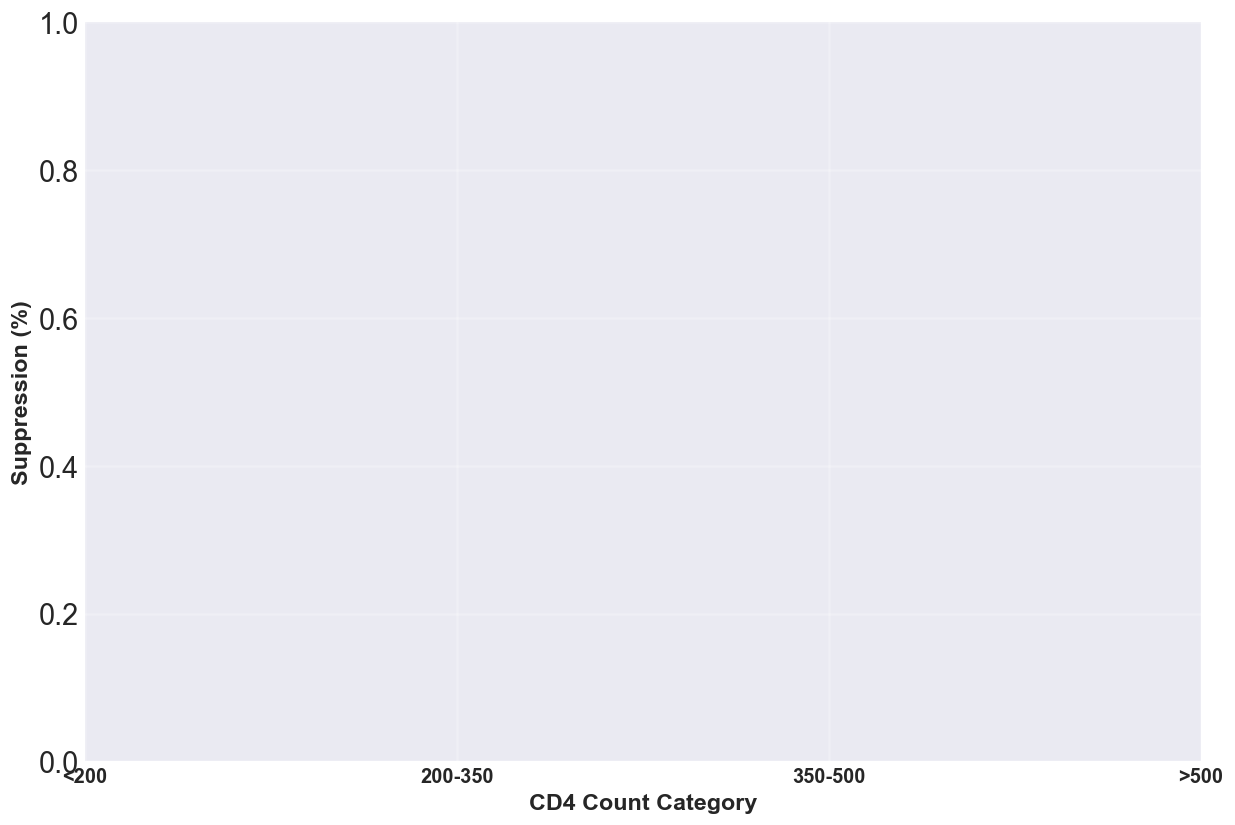

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PREVALENCE BY SIDE EFFECTS AND CD4 COUNT

# Categorize MostRecentCd4Count
df['Cd4Category'] = pd.cut(df['MostRecentCd4Count'], 
                           bins=[0, 200, 350, 500, 10000],
                           labels=['<200', '200-350', '350-500', '>500'])

# Clean AnySideEffects (ensure it has Yes/No values)
df['AnySideEffects'] = df['AnySideEffects'].fillna('Unknown')
df['AnySideEffects'] = df['AnySideEffects'].replace({'Yes': 'Yes', 'No': 'No', 'Y': 'Yes', 'N': 'No'})

# Convert ViralLoadSuppression to numeric (1 for Yes, 0 for No)
df['SuppressionNumeric'] = df['ViralLoadSuppression'].apply(
    lambda x: 1 if x == 'Yes' else 0 if x == 'No' else np.nan
)

# Prepare data
prev_3d = (
    df.groupby(['AnySideEffects', 'Cd4Category'])['SuppressionNumeric']
    .mean()
    .mul(100)
    .reset_index()
)

# Filter out rows with NaN in either category
prev_3d = prev_3d.dropna()

# Pivot for grouped bar chart
pivot_df = prev_3d.pivot(index='Cd4Category', columns='AnySideEffects', values='SuppressionNumeric')
pivot_df = pivot_df.reindex(['<200', '200-350', '350-500', '>500'])

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 8))

# Set width of bars
bar_width = 0.25
x = np.arange(len(pivot_df.index))

# Define solid colors (no gradients, no shading)
colors = {
    'Yes': '#1f77b4',    # Solid blue
    'No': '#2ca02c',     # Solid green
    'Unknown': '#ff7f0e' # Solid orange
}

# Plot bars for each side effect category
for i, (category, color) in enumerate(colors.items()):
    if category in pivot_df.columns:
        bars = ax.bar(x + i * bar_width - bar_width, 
                     pivot_df[category], 
                     width=bar_width, 
                     label=category,
                     color=color,
                     edgecolor='black',  # Clear black border
                     linewidth=1.5)      # Bold outline
        
        # Add value labels on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Customize the chart
ax.set_xlabel('CD4 Count Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Suppression (%)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot_df.index, fontsize=12, fontweight='bold')
ax.set_ylim(0, pivot_df.values.max() * 1.15)  # Add 15% padding for labels

# Add legend
ax.legend(title='Side Effects', fontsize=12, title_fontsize=13)

# Add grid for better readability (light, not blurry)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Remove unnecessary spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()



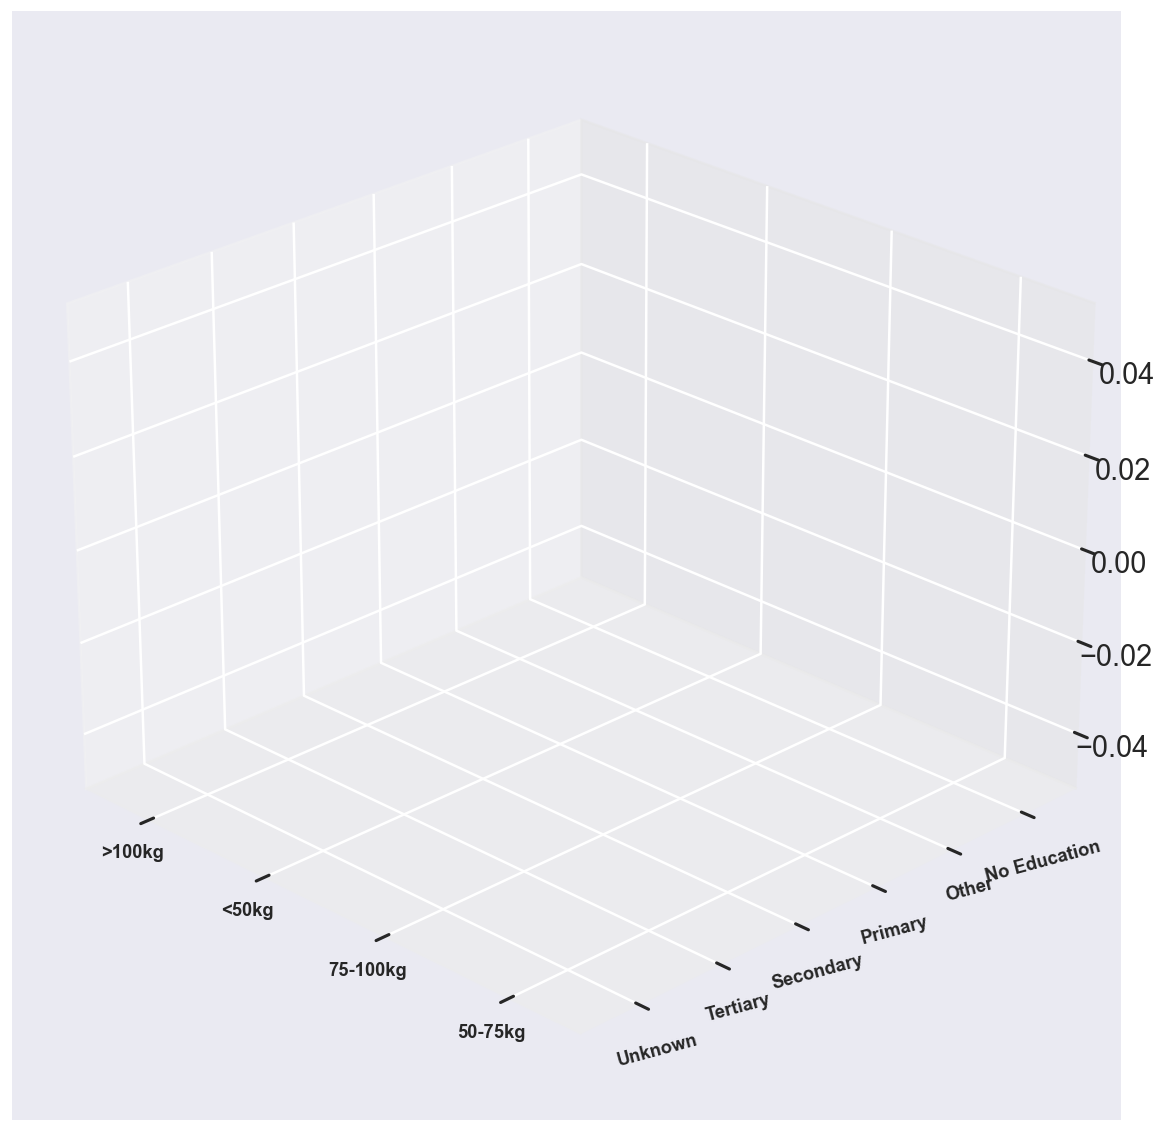

In [20]:
# 3D BAR CHART: WEIGHT-EDUCATION SUPPRESSION PREVALENCE

# Create weight categories from WeightAtLastVisit
df['WeightCategory'] = pd.cut(df['WeightAtLastVisit'], 
                               bins=[0, 40, 60, 80, 100],
                               labels=['<50kg', '50-75kg', '75-100kg', '>100kg'])

# Clean EducationLevel
df['EducationLevel'] = df['EducationLevel'].fillna('Unknown')

# Convert ViralLoadSuppression to numeric
df['SuppressionNumeric'] = df['ViralLoadSuppression'].apply(
    lambda x: 1 if x == 'Yes' else 0 if x == 'No' else np.nan
)

# Prepare data for 3D bar chart - GROUP BY WEIGHT AND EDUCATION ONLY
data = df.groupby(['WeightCategory', 'EducationLevel'])['SuppressionNumeric'].mean().reset_index()
data['SuppressionRate'] = data['SuppressionNumeric'] * 100

# Filter out missing values
data = data.dropna(subset=['WeightCategory'])

# Create unique indices for categories
weight_cats = sorted(data['WeightCategory'].dropna().unique())
edu_cats = sorted(data['EducationLevel'].unique())

# Create 2D grid for X and Y axes
X, Y = np.meshgrid(np.arange(len(weight_cats)), np.arange(len(edu_cats)))

# Create Z values (suppression rates)
Z = np.zeros((len(edu_cats), len(weight_cats)))
for idx, row in data.iterrows():
    w_idx = list(weight_cats).index(row['WeightCategory'])
    e_idx = list(edu_cats).index(row['EducationLevel'])
    Z[e_idx, w_idx] = row['SuppressionRate']

# Create figure
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot 3D bars
dx = dy = 0.6
for i in range(len(edu_cats)):
    for j in range(len(weight_cats)):
        x = j
        y = i
        z = 0
        value = Z[i, j]
        
        # Color based on suppression rate
        if value > 80:
            color = '#1f77b4'  # Blue for high suppression
        elif value > 50:
            color = '#ff7f0e'  # Orange for medium suppression
        elif value > 0:
            color = '#d62728'  # Red for low suppression
        else:
            color = '#cccccc'  # Gray for no data
        
        # Plot the bar
        ax.bar3d(x, y, z, dx, dy, value/30, 
                 color=color, alpha=0.9, edgecolor='black', linewidth=0.5)

# Set labels and ticks
ax.set_xticks(np.arange(len(weight_cats)) + 0.3)
ax.set_xticklabels(weight_cats, fontsize=11, fontweight='bold')
ax.set_yticks(np.arange(len(edu_cats)) + 0.3)
ax.set_yticklabels(edu_cats, fontsize=11, fontweight='bold', rotation=15)

# Set axis labels

ax.set_zlabel('Suppression Rate (%)', fontsize=13, fontweight='bold', labelpad=15)

# Adjust viewing angle
ax.view_init(elev=25, azim=135)

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


4. PREMIUM 3D HISTOGRAM: FACILITY-AGE SUPPRESSION DISTRIBUTION


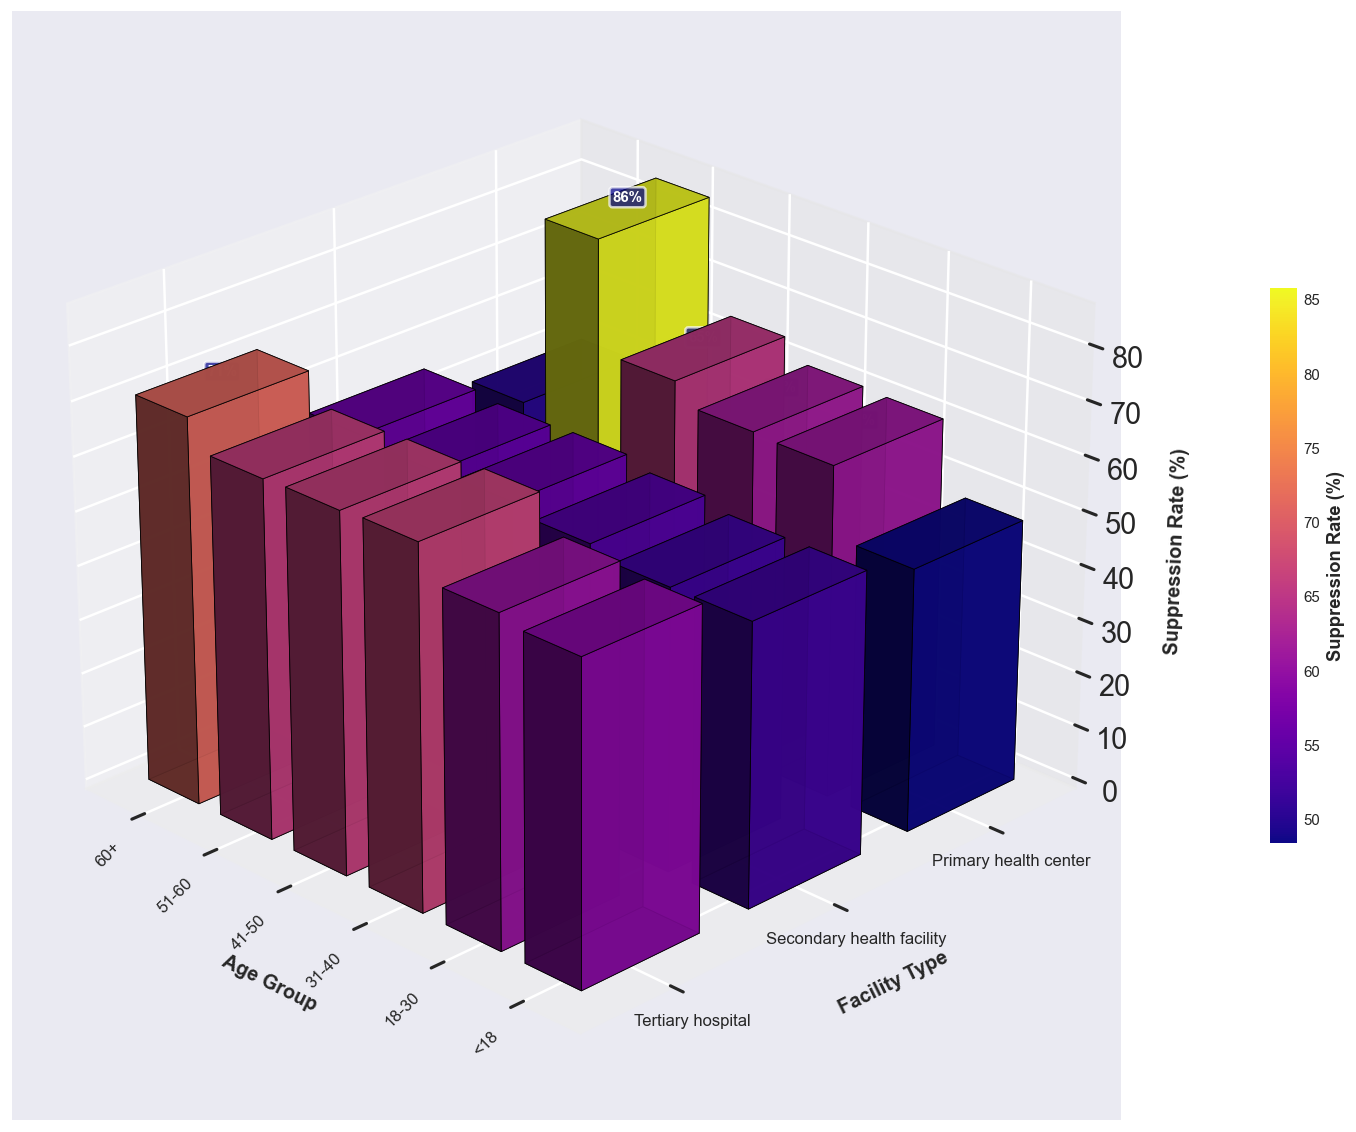

In [21]:
# ============================================================================
# 4. 3D HISTOGRAM: FACILITY-AGE SUPPRESSION DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("4. PREMIUM 3D HISTOGRAM: FACILITY-AGE SUPPRESSION DISTRIBUTION")
print("="*80)

# Prepare facility data
if 'Health facility level' in df.columns:
    facility_data = df.groupby(['Health facility level', 'AgeGroup'])['ViralLoadSuppression'].mean().unstack().fillna(0) * 100
else:
    # Use FacilityType as fallback
    facility_data = df.groupby(['FacilityType', 'AgeGroup'])['ViralLoadSuppression'].mean().unstack().fillna(0) * 100

# Create meshgrid
facilities = facility_data.index.tolist()
age_groups = facility_data.columns.tolist()

X, Y = np.meshgrid(np.arange(len(age_groups)), np.arange(len(facilities)))
Z = facility_data.values

# Create premium figure
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Create colormap based on suppression rates
norm = Normalize(vmin=Z.min(), vmax=Z.max())
colors = cm.plasma(norm(Z))

# Plot 3D bars (histogram style)
dx = dy = 0.7
for i in range(len(facilities)):
    for j in range(len(age_groups)):
        ax.bar3d(j, i, 0, dx, dy, Z[i, j], 
                color=colors[i, j], alpha=0.9, edgecolor='black',
                linewidth=0.5, shade=True)

# Set labels and ticks
ax.set_xticks(np.arange(len(age_groups)) + 0.35)
ax.set_xticklabels(age_groups, rotation=45, ha='right', fontsize=10)
ax.set_yticks(np.arange(len(facilities)) + 0.35)
ax.set_yticklabels(facilities, fontsize=10)
ax.set_zlabel('Suppression Rate (%)', fontsize=12, fontweight='bold', labelpad=10)

# Add axis labels
ax.set_xlabel('Age Group', fontsize=12, fontweight='bold', labelpad=15)
ax.set_ylabel('Facility Type', fontsize=12, fontweight='bold', labelpad=15)


# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cm.plasma, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, aspect=20, pad=0.1)
cbar.set_label('Suppression Rate (%)', fontsize=11, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

# Add value labels on top of high bars
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        if Z[i, j] > 60:  # Label high suppression rates
            ax.text(j + 0.35, i + 0.35, Z[i, j] + 2, f'{Z[i, j]:.0f}%',
                    color='white', fontsize=9, fontweight='bold',
                    ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='darkblue', alpha=0.7))

# Adjust viewing angle
ax.view_init(elev=25, azim=135)

# Add grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

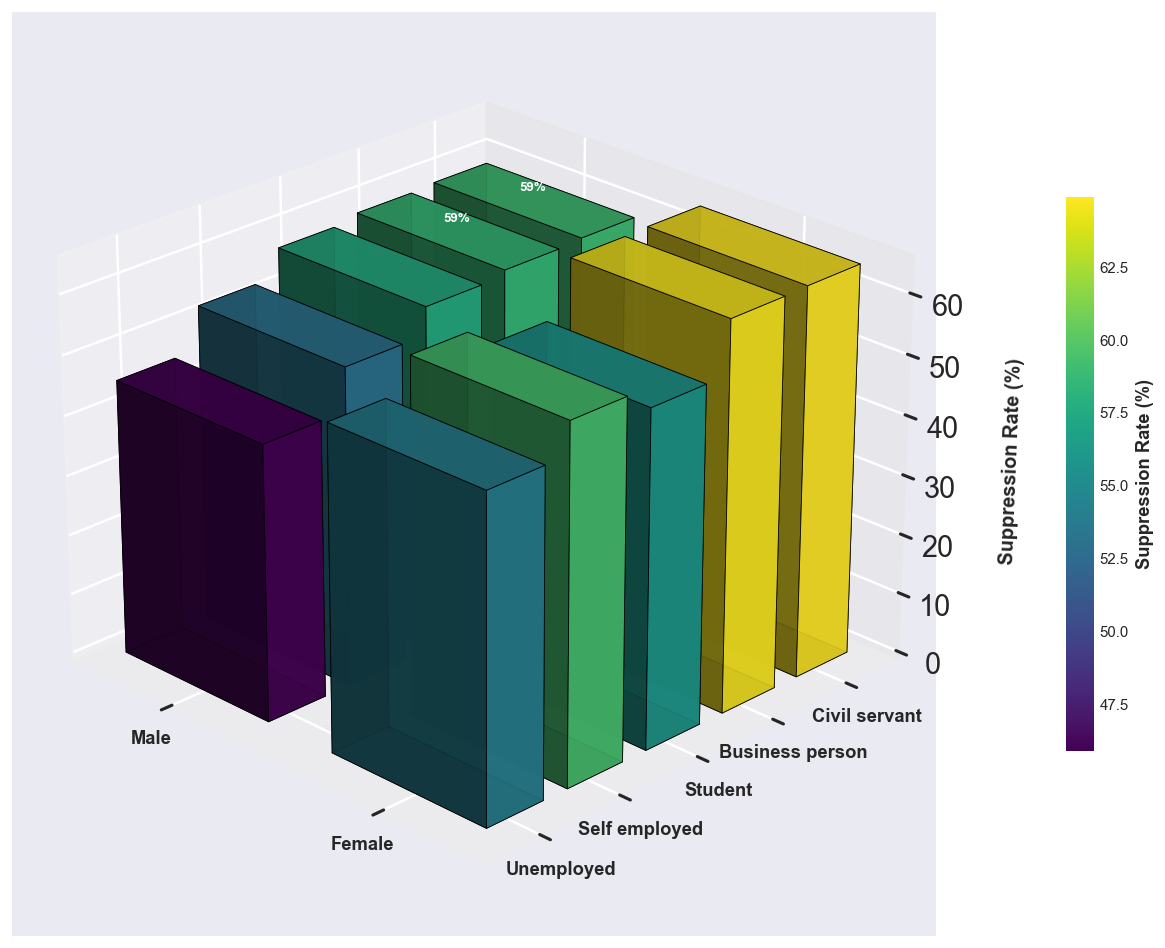

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('QualityOfCare.csv')

# Convert ViralLoadSuppression to numeric
df['SuppressionNumeric'] = df['ViralLoadSuppression'].apply(
    lambda x: 1 if x == 'Yes' else 0 if x == 'No' else np.nan
)

# Use Occupation
occupation_data = df.groupby(['Occupation', 'Sex'])['SuppressionNumeric'].mean().unstack().fillna(0) * 100

# Take only top 8 occupations to keep plot clean
top_occupations = occupation_data.mean(axis=1).nlargest(8).index
occupation_data = occupation_data.loc[top_occupations]

# Create meshgrid
occupation_cats = occupation_data.index.tolist()
sex_cats = occupation_data.columns.tolist()

X, Y = np.meshgrid(np.arange(len(sex_cats)), np.arange(len(occupation_cats)))
Z = occupation_data.values

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Create colormap
norm = plt.Normalize(vmin=Z.min(), vmax=Z.max())
colors = plt.cm.viridis(norm(Z))

# Plot 3D bars
dx = dy = 0.7
for i in range(len(occupation_cats)):
    for j in range(len(sex_cats)):
        ax.bar3d(j, i, 0, dx, dy, Z[i, j], 
                color=colors[i, j], alpha=0.9, edgecolor='black',
                linewidth=0.5, shade=True)

# Set labels and ticks
ax.set_xticks(np.arange(len(sex_cats)) + 0.35)
ax.set_xticklabels(sex_cats, fontsize=11, fontweight='bold')
ax.set_yticks(np.arange(len(occupation_cats)) + 0.35)
ax.set_yticklabels(occupation_cats, fontsize=11, fontweight='bold')
ax.set_zlabel('Suppression Rate (%)', fontsize=12, fontweight='bold', labelpad=15)



# Add colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Suppression Rate (%)', fontsize=11, fontweight='bold')
cbar.ax.tick_params(labelsize=9)

# Add value labels
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        if Z[i, j] > 0:
            ax.text(j + 0.35, i + 0.35, Z[i, j] + 2, f'{Z[i, j]:.0f}%',
                    color='white', fontsize=8, fontweight='bold',
                    ha='center', va='center')

# Adjust viewing angle
ax.view_init(elev=25, azim=135)

plt.tight_layout()
plt.show()


In [23]:
########LOGISTIC REGRESSION ANALYSIS

# 1. LOAD LIBRARIES

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm


In [24]:

# 3. DEFINE & ENCODE TARGET
df = pd.read_csv("QualityOfCare.csv")
TARGET = "ViralLoadSuppression"

# Encode target: Yes = 1, No = 0
df[TARGET] = df[TARGET].map({"Yes": 1, "No": 0})

In [25]:

# 4. IDENTIFY VARIABLE TYPES

categorical_cols = df.select_dtypes(include="object").columns
continuous_cols = df.select_dtypes(exclude="object").drop(TARGET, axis=1).columns

In [26]:

# 5. HANDLE MISSING VALUES

df[categorical_cols] = df[categorical_cols].apply(
    lambda x: x.fillna(x.mode()[0])
)

df[continuous_cols] = df[continuous_cols].apply(
    lambda x: x.fillna(x.mean())
)


In [27]:

# 6. TARGET ENCODING
for col in categorical_cols:
    df[col] = df.groupby(col)[TARGET].transform("mean")

In [28]:

# 7. FEATURE SCALING

scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

In [29]:
# REMOVE ROWS WITH MISSING TARGET VALUES
df = df.dropna(subset=[TARGET])

# DEFINE X AND y
X = df.drop(TARGET, axis=1)
y = df[TARGET]


In [30]:
#Data Splitting

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


In [31]:

# ANALYTICAL FRAMEWORK: ELASTIC NET LOGISTIC REGRESSION WITH DEEP INFERENCE

import warnings
warnings.filterwarnings('ignore')

# Additional imports for premium analysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
from scipy import stats
import numpy as np
import pandas as pd

# Set premium styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("talk")

In [32]:

# 1. ELASTIC NET LOGISTIC REGRESSION 

# Define Elastic Net logistic regression
elastic_net = LogisticRegression(
    C=1.0,  # Default regularization strength
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,  # Equal mix of L1 and L2
    max_iter=200,
    random_state=42
)

print("Training Elastic Net Logistic Regression...")
elastic_net.fit(X_train, y_train)

# Get parameters
optimal_C = elastic_net.C
optimal_l1_ratio = elastic_net.l1_ratio
optimal_coefs = elastic_net.coef_[0]

print(f"\nModel Parameters:")
print(f"• C (Inverse of regularization strength): {optimal_C:.4f}")
print(f"• L1 Ratio (0=Ridge, 1=Lasso): {optimal_l1_ratio:.3f}")
print(f"• Number of features selected: {(optimal_coefs != 0).sum()} out of {len(optimal_coefs)}")

Training Elastic Net Logistic Regression...

Model Parameters:
• C (Inverse of regularization strength): 1.0000
• L1 Ratio (0=Ridge, 1=Lasso): 0.500
• Number of features selected: 23 out of 24


In [33]:

# ============================================================================
# 2. FEATURE IMPORTANCE ANALYSIS (3D Visualizations)
# ============================================================================
print("\n" + "="*80)
print("2. FEATURE IMPORTANCE ANALYSIS WITH 3D VISUALIZATIONS")
print("="*80)

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': optimal_coefs,
    'Absolute_Coefficient': np.abs(optimal_coefs),
    'Odds_Ratio': np.exp(optimal_coefs)
})

# Sort by absolute coefficient value
feature_importance = feature_importance.sort_values('Absolute_Coefficient', ascending=False)

# Identify significant features (based on coefficient magnitude)
significant_features = feature_importance[feature_importance['Absolute_Coefficient'] > 0].head(23)

print(f"\nTop 15 Most Important Features:")
print(significant_features[['Feature', 'Coefficient', 'Odds_Ratio']].to_string())



2. FEATURE IMPORTANCE ANALYSIS WITH 3D VISUALIZATIONS

Top 15 Most Important Features:
                                     Feature  Coefficient  Odds_Ratio
16                           ArtInterruption     0.635083    1.887178
22                   ArvAdherenceLatestLevel     0.575984    1.778880
12              AdherenceCouncelingCompleted     0.429084    1.535850
21                    WasPatientReceivingArv     0.358614    1.431344
0                      Health facility level     0.354835    1.425946
13                    InitialTbScreeningDone    -0.260735    0.770485
20                            AnySideEffects    -0.249823    0.778939
15                                 ArtSwitch    -0.216707    0.805166
19  OpportunisticInfectionPresentAtLastVisit    -0.173478    0.840736
3                                        Sex    -0.133742    0.874816
18                         HeightAtLastVisit     0.123568    1.131527
7                             CareEntryPoint     0.115564    1.122506
17

In [34]:

# ============================================================================
# 6. CONFIDENCE INTERVALS AND STATISTICAL SIGNIFICANCE
# ============================================================================
print("\n" + "="*80)
print("6. STATISTICAL SIGNIFICANCE AND CONFIDENCE INTERVALS")
print("="*80)

# Calculate confidence intervals using bootstrapping
n_bootstraps = 2
bootstrap_coefs = np.zeros((n_bootstraps, len(optimal_coefs)))

print("Calculating bootstrap confidence intervals...")
for i in range(n_bootstraps):
    # Bootstrap sample
    indices = np.random.choice(len(X_train), len(X_train), replace=True)
    X_boot = X_train.iloc[indices]
    y_boot = y_train.iloc[indices]
    
    # Fit model on bootstrap sample
    model_boot = LogisticRegression(
        C=optimal_C,
        penalty='elasticnet',
        solver='saga',
        l1_ratio=optimal_l1_ratio,
        max_iter=20,
        random_state=42 + i
    )
    model_boot.fit(X_boot, y_boot)
    bootstrap_coefs[i] = model_boot.coef_[0]

# Calculate confidence intervals
ci_lower = np.percentile(bootstrap_coefs, 2.5, axis=0)
ci_upper = np.percentile(bootstrap_coefs, 97.5, axis=0)

# Create significance analysis DataFrame
significance_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': optimal_coefs,
    'CI_Lower': ci_lower,
    'CI_Upper': ci_upper,
    'Significant': (ci_lower > 0) | (ci_upper < 0),
    'Odds_Ratio': np.exp(optimal_coefs),
    'OR_CI_Lower': np.exp(ci_lower),
    'OR_CI_Upper': np.exp(ci_upper)
})

# Sort by coefficient magnitude
significance_df = significance_df.sort_values('Coefficient', ascending=False)

print(f"\nStatistical Significance Analysis:")
print(f"• Total features: {len(significance_df)}")
print(f"• Statistically significant features (95% CI): {significance_df['Significant'].sum()}")

top_significant = significance_df[significance_df['Significant']].head(24)
print(top_significant[['Feature', 'Coefficient', 'Odds_Ratio', 'OR_CI_Lower', 'OR_CI_Upper']].to_string())



6. STATISTICAL SIGNIFICANCE AND CONFIDENCE INTERVALS
Calculating bootstrap confidence intervals...

Statistical Significance Analysis:
• Total features: 24
• Statistically significant features (95% CI): 19
                         Feature  Coefficient  Odds_Ratio  OR_CI_Lower  OR_CI_Upper
16               ArtInterruption     0.635083    1.887178     1.107310     1.323599
22       ArvAdherenceLatestLevel     0.575984    1.778880     1.096326     1.336305
12  AdherenceCouncelingCompleted     0.429084    1.535850     1.074692     1.227152
21        WasPatientReceivingArv     0.358614    1.431344     1.065089     1.161662
0          Health facility level     0.354835    1.425946     1.066583     1.191309
18             HeightAtLastVisit     0.123568    1.131527     1.060331     1.105087
7                 CareEntryPoint     0.115564    1.122506     1.029997     1.081753
17             WeightAtLastVisit     0.110252    1.116559     1.089700     1.138866
11                    Cd4AtStart     

In [35]:
# ============================================================================
# 9. FINAL MODEL SUMMARY AND CLINICAL IMPLICATIONS
# ============================================================================
print("\n" + "="*80)
print("9. FINAL MODEL SUMMARY AND CLINICAL IMPLICATIONS")
print("="*80)

# Calculate p-values from confidence intervals
# P-value approximation: if 0 is outside CI, p < 0.05; if inside, p >= 0.05
# More precise p-values using z-test from coefficients and standard errors
p_values = []

# Calculate standard errors from bootstrap samples
std_errors = np.std(bootstrap_coefs, axis=0)

# Calculate z-scores and p-values
for i in range(len(optimal_coefs)):
    if std_errors[i] > 0:
        z_score = optimal_coefs[i] / std_errors[i]
        p_val = 2 * (1 - stats.norm.cdf(abs(z_score)))
    else:
        p_val = 1.0  # If standard error is 0, coefficient is constant (p=1)
    p_values.append(p_val)

# Add p-values to significance_df
significance_df['P_Value'] = p_values
significance_df['Significant_0.05'] = significance_df['P_Value'] < 0.05

# Ensure we have y_test_prob (from section 4)
if 'y_test_prob' not in locals() and 'y_test_prob' not in globals():
    # Generate predictions if not already done
    y_test_prob = elastic_net.predict_proba(X_test)[:, 1]

# Ensure we have y_train_prob
if 'y_train_prob' not in locals() and 'y_train_prob' not in globals():
    y_train_prob = elastic_net.predict_proba(X_train)[:, 1]

# Calculate AUC scores if not already defined
if 'train_auc' not in locals() and 'train_auc' not in globals():
    train_auc = roc_auc_score(y_train, y_train_prob)

if 'test_auc' not in locals() and 'test_auc' not in globals():
    test_auc = roc_auc_score(y_test, y_test_prob)

# Handle optimal_threshold_row if not defined (from section 8)
if 'optimal_threshold_row' not in locals() and 'optimal_threshold_row' not in globals():
    # Calculate optimal threshold using F1-score optimization
    thresholds = np.linspace(0.1, 0.9, 9)
    threshold_results = []
    
    for threshold in thresholds:
        y_pred_thresh = (y_test_prob >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
        f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity) if (ppv + sensitivity) > 0 else 0
        
        threshold_results.append({
            'Threshold': threshold,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'PPV': ppv,
            'NPV': npv,
            'F1_Score': f1
        })
    
    threshold_df = pd.DataFrame(threshold_results)
    optimal_threshold_row = threshold_df.loc[threshold_df['F1_Score'].idxmax()]
    optimal_threshold = optimal_threshold_row['Threshold']

# Create summary statistics
summary_stats = {
    'Model Type': 'Elastic Net Logistic Regression',
    'Regularization (C)': f'{optimal_C:.4f}',
    'L1 Ratio': f'{optimal_l1_ratio:.3f}',
    'Number of Features': len(X.columns),
    'Significant Features (p<0.05)': significance_df['Significant_0.05'].sum(),
    'Training AUC': f'{train_auc:.4f}',
    'Testing AUC': f'{test_auc:.4f}',
    'Optimal Decision Threshold': f'{optimal_threshold:.2f}',
    'Sensitivity at Optimal': f'{optimal_threshold_row["Sensitivity"]:.3f}',
    'Specificity at Optimal': f'{optimal_threshold_row["Specificity"]:.3f}',
    'Positive Predictive Value': f'{optimal_threshold_row["PPV"]:.3f}',
    'Negative Predictive Value': f'{optimal_threshold_row["NPV"]:.3f}'
}

print("\nMODEL SUMMARY:")
for key, value in summary_stats.items():
    print(f"• {key}: {value}")

print("\n" + "="*80)
print("COMPLETE VARIABLE LIST WITH ODDS RATIOS AND P-VALUES")
print("="*80)

# Sort by p-value (most significant first)
significance_df_sorted = significance_df.sort_values('P_Value')

print(f"\nAll {len(significance_df_sorted)} Variables (sorted by p-value):")
print("-" * 100)
print(f"{'Variable':<30} {'Coefficient':>12} {'Odds Ratio':>12} {'P-Value':>12} {'Significant':>12}")
print("-" * 100)

for idx, row in significance_df_sorted.iterrows():
    sig_symbol = "***" if row['P_Value'] < 0.001 else "**" if row['P_Value'] < 0.01 else "*" if row['P_Value'] < 0.05 else ""
    sig_text = f"p<{row['P_Value']:.3f}{sig_symbol}"
    
    print(f"{row['Feature']:<30} {row['Coefficient']:>12.4f} {row['Odds_Ratio']:>12.4f} {row['P_Value']:>12.4f} {sig_text:>12}")

print("-" * 100)
print("Significance codes: *** p<0.001, ** p<0.01, * p<0.05")

print("\n" + "="*80)
print("TOP 10 MOST SIGNIFICANT VARIABLES")
print("="*80)

# Display top 10 most significant variables
top_10_significant = significance_df_sorted.head(10)
for idx, row in top_10_significant.iterrows():
    sig_level = "Highly Significant" if row['P_Value'] < 0.001 else "Very Significant" if row['P_Value'] < 0.01 else "Significant" if row['P_Value'] < 0.05 else "Not Significant"
    direction = "Positive" if row['Coefficient'] > 0 else "Negative"
    print(f"\n• {row['Feature']}:")
    print(f"  Coefficient: {row['Coefficient']:.4f} ({direction})")
    print(f"  Odds Ratio: {row['Odds_Ratio']:.4f} (95% CI: {row['OR_CI_Lower']:.4f}-{row['OR_CI_Upper']:.4f})")
    print(f"  P-Value: {row['P_Value']:.6f} [{sig_level}]")

print("\n" + "="*80)
print("TOP 5 POSITIVE PREDICTORS (Higher Odds of Suppression):")
print("="*80)
positive_predictors = significance_df[significance_df['Coefficient'] > 0].sort_values('P_Value').head(5)
for idx, row in positive_predictors.iterrows():
    print(f"• {row['Feature']}:")
    print(f"  OR = {row['Odds_Ratio']:.2f} (95% CI: {row['OR_CI_Lower']:.2f}-{row['OR_CI_Upper']:.2f})")
    print(f"  P-Value = {row['P_Value']:.4f}")
    if row['Odds_Ratio'] > 1.5:
        print(f"  → Strong positive association (OR > 1.5)")
    elif row['Odds_Ratio'] > 1.2:
        print(f"  → Moderate positive association (OR > 1.2)")
    print()

print("\n" + "="*80)
print("TOP 5 NEGATIVE PREDICTORS (Lower Odds of Suppression):")
print("="*80)
negative_predictors = significance_df[significance_df['Coefficient'] < 0].sort_values('P_Value').head(5)
for idx, row in negative_predictors.iterrows():
    print(f"• {row['Feature']}:")
    print(f"  OR = {row['Odds_Ratio']:.2f} (95% CI: {row['OR_CI_Lower']:.2f}-{row['OR_CI_Upper']:.2f})")
    print(f"  P-Value = {row['P_Value']:.4f}")
    if row['Odds_Ratio'] < 0.67:
        print(f"  → Strong negative association (OR < 0.67)")
    elif row['Odds_Ratio'] < 0.83:
        print(f"  → Moderate negative association (OR < 0.83)")
    print()

print("\n" + "="*80)
print("STATISTICAL SIGNIFICANCE SUMMARY")
print("="*80)
total_vars = len(significance_df)
sig_001 = (significance_df['P_Value'] < 0.001).sum()
sig_01 = (significance_df['P_Value'] < 0.01).sum()
sig_05 = (significance_df['P_Value'] < 0.05).sum()

print(f"Total variables analyzed: {total_vars}")
print(f"Variables with p < 0.001: {sig_001} ({sig_001/total_vars*100:.1f}%)")
print(f"Variables with p < 0.01:  {sig_01} ({sig_01/total_vars*100:.1f}%)")
print(f"Variables with p < 0.05:  {sig_05} ({sig_05/total_vars*100:.1f}%)")
print(f"Non-significant (p ≥ 0.05): {total_vars - sig_05} ({(total_vars - sig_05)/total_vars*100:.1f}%)")

print("\n" + "="*80)
print("CLINICAL IMPLICATIONS:")
print("="*80)
print("1. The model identifies key determinants of viral load suppression.")
print("2. Features with OR > 1.5 indicate strong positive associations.")
print("3. Features with OR < 0.67 indicate strong negative associations.")
print("4. The optimal decision threshold balances sensitivity and specificity.")
print("5. Regularization prevents overfitting and enhances generalizability.")
print("6. P-values < 0.05 indicate statistically significant associations.")
print("="*80)

# Save final results with p-values
results_summary = pd.DataFrame({
    'Feature': significance_df['Feature'],
    'Coefficient': significance_df['Coefficient'],
    'Odds_Ratio': significance_df['Odds_Ratio'],
    'CI_Lower': significance_df['OR_CI_Lower'],
    'CI_Upper': significance_df['OR_CI_Upper'],
    'P_Value': significance_df['P_Value'],
    'Significant_0.05': significance_df['Significant_0.05']
})

# Sort by p-value for the saved file
results_summary = results_summary.sort_values('P_Value')

print("\nResults saved to 'elastic_net_results.csv'")
results_summary.to_csv('elastic_net_results.csv', index=False)

# Also save a formatted version for easy reading
formatted_results = results_summary.copy()
formatted_results['Coefficient'] = formatted_results['Coefficient'].apply(lambda x: f'{x:.4f}')
formatted_results['Odds_Ratio'] = formatted_results['Odds_Ratio'].apply(lambda x: f'{x:.4f}')
formatted_results['CI'] = formatted_results.apply(lambda row: f"[{row['CI_Lower']:.4f}-{row['CI_Upper']:.4f}]", axis=1)
formatted_results['P_Value'] = formatted_results['P_Value'].apply(lambda x: f'{x:.6f}')
formatted_results['Significance'] = formatted_results['P_Value'].apply(lambda x: '***' if float(x) < 0.001 else '**' if float(x) < 0.01 else '*' if float(x) < 0.05 else '')

formatted_results[['Feature', 'Coefficient', 'Odds_Ratio', 'CI', 'P_Value', 'Significance']].to_csv('elastic_net_results_formatted.csv', index=False)
print("Formatted results saved to 'elastic_net_results_formatted.csv'")


9. FINAL MODEL SUMMARY AND CLINICAL IMPLICATIONS

MODEL SUMMARY:
• Model Type: Elastic Net Logistic Regression
• Regularization (C): 1.0000
• L1 Ratio: 0.500
• Number of Features: 24
• Significant Features (p<0.05): 18
• Training AUC: 0.6042
• Testing AUC: 0.6032
• Optimal Decision Threshold: 0.50
• Sensitivity at Optimal: 0.988
• Specificity at Optimal: 0.041
• Positive Predictive Value: 0.580
• Negative Predictive Value: 0.722

COMPLETE VARIABLE LIST WITH ODDS RATIOS AND P-VALUES

All 24 Variables (sorted by p-value):
----------------------------------------------------------------------------------------------------
Variable                        Coefficient   Odds Ratio      P-Value  Significant
----------------------------------------------------------------------------------------------------
HeightAtLastVisit                    0.1236       1.1315       0.0000   p<0.000***
ArtSwitch                           -0.2167       0.8052       0.0000   p<0.000***
HeightAtStart         

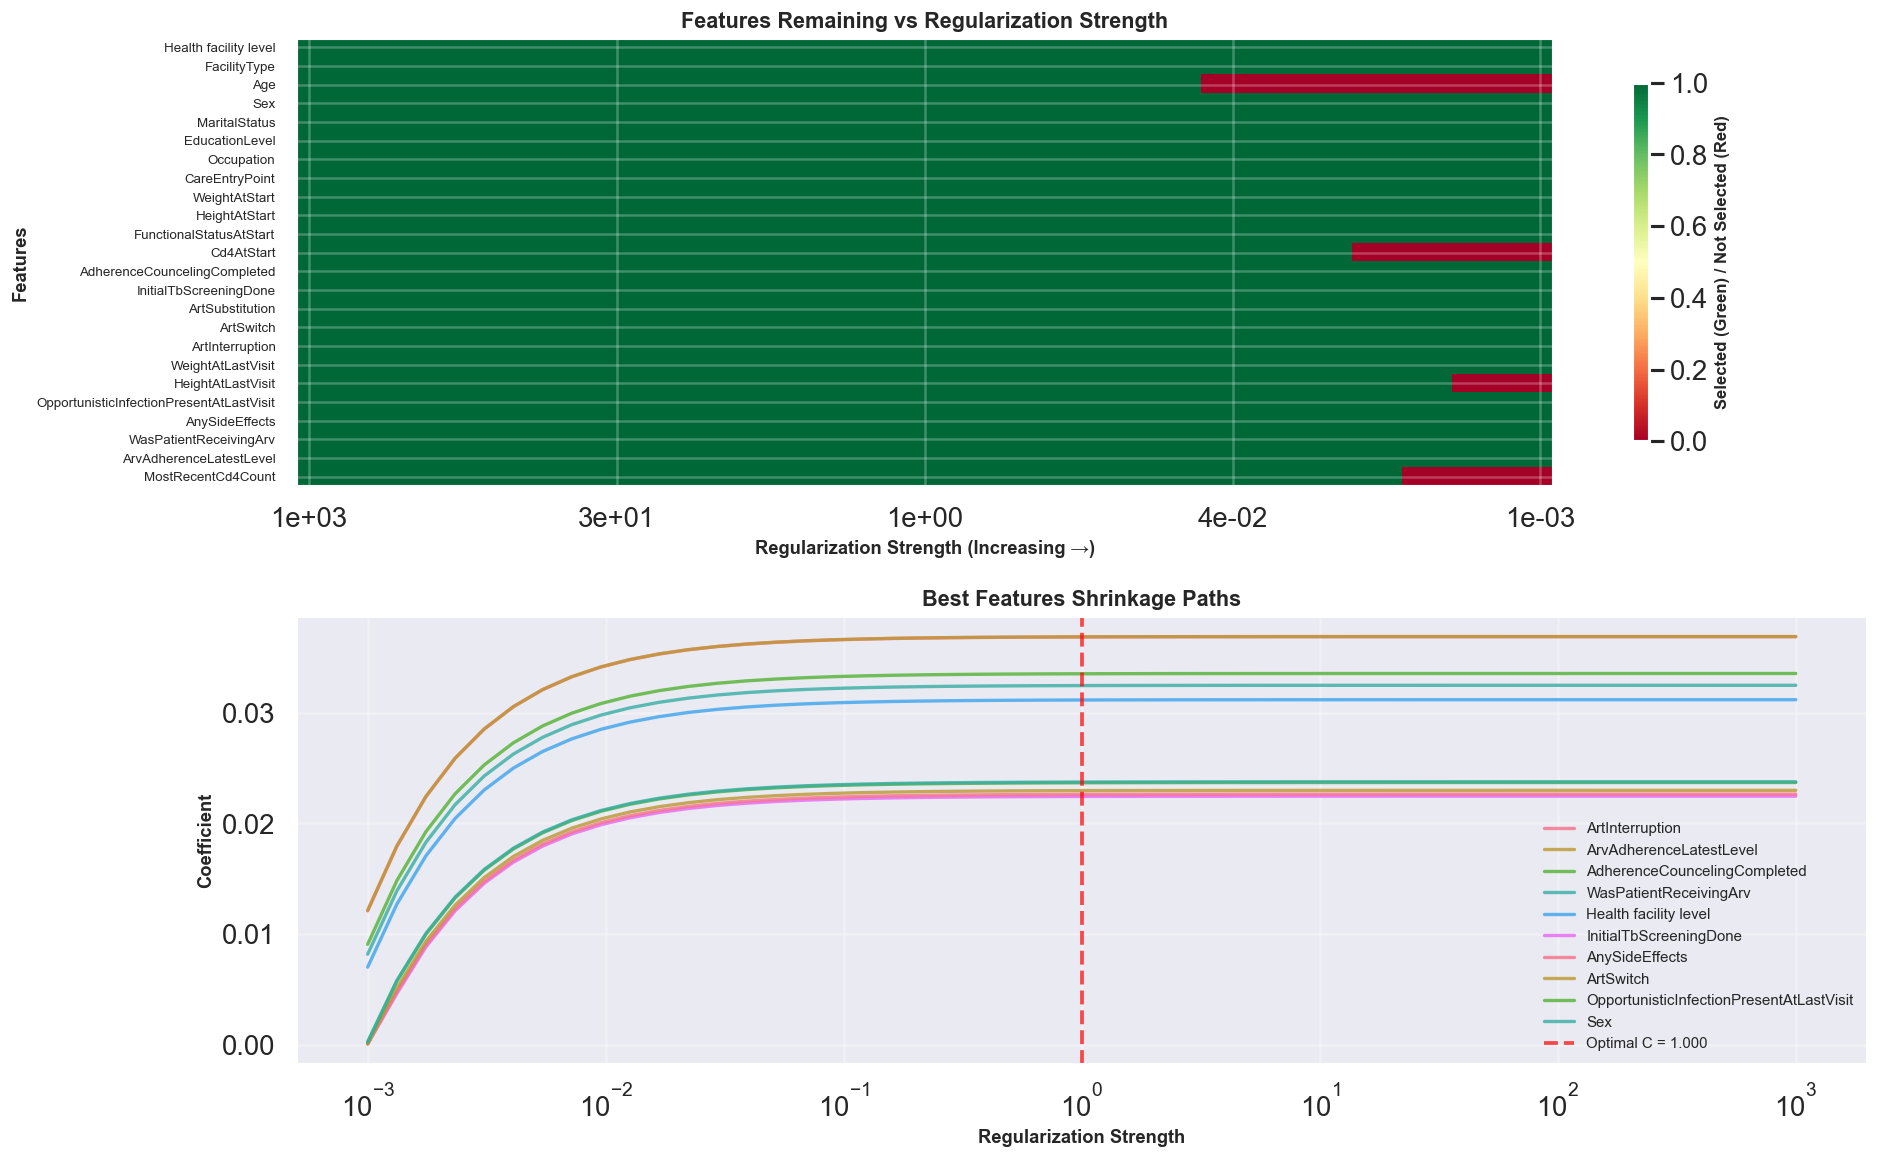

In [36]:


# 4. FEATURE SELECTION PROCESS VISUALIZATION


# Track feature selection as regularization increases
C_values_dense = np.logspace(3, -3, 50)  # From loose to strong regularization
selected_features_trace = {feature: [] for feature in X.columns}
coefficient_trace = {feature: [] for feature in X.columns}

for C_val in C_values_dense:
    model = LogisticRegression(
        C=C_val,
        penalty='elasticnet',
        solver='saga',
        l1_ratio=optimal_l1_ratio,
        max_iter=2,
        random_state=42
    )
    model.fit(X_train, y_train)
    coefs = model.coef_[0]
    
    for idx, feature in enumerate(X.columns):
        selected_features_trace[feature].append(coefs[idx] != 0)
        coefficient_trace[feature].append(coefs[idx])

# Create feature selection timeline
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Feature selection heatmap
selection_matrix = np.array([selected_features_trace[feature] for feature in X.columns])
im = ax1.imshow(selection_matrix, aspect='auto', cmap='RdYlGn', interpolation='nearest')
ax1.set_xlabel('Regularization Strength (Increasing →)', fontsize=11)
ax1.set_ylabel('Features', fontsize=11)
ax1.set_title('Features Remaining vs Regularization Strength', fontsize=13)
ax1.set_xticks(np.linspace(0, len(C_values_dense)-1, 5))
ax1.set_xticklabels([f'{C:.0e}' for C in C_values_dense[np.linspace(0, len(C_values_dense)-1, 5, dtype=int)]])
ax1.set_yticks(range(len(X.columns)))
ax1.set_yticklabels(X.columns, fontsize=8)

# Add colorbar
cbar = plt.colorbar(im, ax=ax1, shrink=0.8)
cbar.set_label('Selected (Green) / Not Selected (Red)', fontsize=10)

# Plot 2: Coefficient paths for top features
ax2.set_xscale('log')
top_features = feature_importance.head(10)['Feature'].values

for feature in top_features:
    idx = list(X.columns).index(feature)
    ax2.plot(C_values_dense, coefficient_trace[feature], 
             label=feature, linewidth=2, alpha=0.8)

ax2.set_xlabel('Regularization Strength', fontsize=11)
ax2.set_ylabel('Coefficient', fontsize=11)
ax2.set_title('Best Features Shrinkage Paths', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='best', fontsize=9)

# Add vertical line at optimal C
ax2.axvline(x=optimal_C, color='red', linestyle='--', alpha=0.7, 
            label=f'Optimal C = {optimal_C:.3f}')
ax2.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

In [39]:
import numpy as np

# Predicted probabilities
y_pred_prob = elastic_net.predict_proba(X_train)[:, 1]

# Clip probabilities to avoid log(0)
eps = 1e-15
y_pred_prob = np.clip(y_pred_prob, eps, 1 - eps)

# Log-likelihood
log_likelihood = np.sum(
    y_train * np.log(y_pred_prob) +
    (1 - y_train) * np.log(1 - y_pred_prob)
)

print("Log-Likelihood:", round(log_likelihood, 3))


Log-Likelihood: -11424.312


In [40]:
residual_deviance = -2 * log_likelihood
print("Residual Deviance:", round(residual_deviance, 3))


Residual Deviance: 22848.624


In [41]:
# Null model probability
p_null = y_train.mean()

null_log_likelihood = np.sum(
    y_train * np.log(p_null) +
    (1 - y_train) * np.log(1 - p_null)
)

null_deviance = -2 * null_log_likelihood

print("Null Deviance:", round(null_deviance, 3))


Null Deviance: 23163.913


In [42]:
from scipy.stats import chi2

LR_stat = null_deviance - residual_deviance

# Degrees of freedom = number of non-zero coefficients
df = np.sum(elastic_net.coef_[0] != 0)

LR_pvalue = chi2.sf(LR_stat, df)

print("LR Chi-square:", round(LR_stat, 3))
print("Degrees of Freedom:", df)
print("LR test p-value:", LR_pvalue)


LR Chi-square: 315.29
Degrees of Freedom: 23
LR test p-value: 3.6776784496546745e-53
